In [1]:
# Cell 0 — Imports & GPU Verification
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

try:
    from imblearn.over_sampling import SMOTE
    print('✓ imbalanced-learn found')
except ImportError:
    os.system('pip install imbalanced-learn -q')
    from imblearn.over_sampling import SMOTE
    print('✓ imbalanced-learn installed')

# ── GPU check ──────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✓ GPU detected: {gpus[0].name}')
    print(f'  Training will use GPU')
else:
    print('⚠ No GPU detected — training on CPU (slow)')

print(f'\nTensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('✓ All libraries loaded!')

✓ imbalanced-learn found
✓ GPU detected: /physical_device:GPU:0
  Training will use GPU

TensorFlow : 2.10.0
NumPy      : 1.26.4
✓ All libraries loaded!


In [2]:
# Cell 1 — Paths & Constants
# ── UPDATE THESE PATHS to match your laptop ────────────────────────────────
train_dir  = r"C:\Project\Starting\Splitted\train"
val_dir    = r"C:\Project\Starting\Splitted\val"
test_dir   = r"C:\Project\Starting\Splitted\test"

MODELS_DIR = r"C:\Project\Starting\models"
os.makedirs(MODELS_DIR, exist_ok=True)
# ───────────────────────────────────────────────────────────────────────────

# DenseNet121 native input size is 224x224
IMG_SIZE         = 224
BATCH_SIZE       = 16    
MAX_CLASS_WEIGHT = 10.0

CLASS_NAMES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print(f'Models will save to : {os.path.abspath(MODELS_DIR)}')
print(f'IMG_SIZE={IMG_SIZE} (DenseNet121 native), BATCH_SIZE={BATCH_SIZE}')
print()
print('After training, copy these 2 files to your web app PC:')
print(f'  {os.path.join(MODELS_DIR, "mri_densenet121_finetuned.keras")}')
print(f'  {os.path.join(MODELS_DIR, "mri_xgb_densenet.pkl")}')

Models will save to : C:\Project\Starting\models
IMG_SIZE=224 (DenseNet121 native), BATCH_SIZE=16

After training, copy these 2 files to your web app PC:
  C:\Project\Starting\models\mri_densenet121_finetuned.keras
  C:\Project\Starting\models\mri_xgb_densenet.pkl


In [17]:
# Cell 2 — Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f'Class indices : {train_gen.class_indices}')
print()
print('Class distribution (train):')
unique, counts = np.unique(train_gen.classes, return_counts=True)
total = counts.sum()
for idx, count in zip(unique, counts):
    print(f'  [{idx}] {CLASS_NAMES[idx]:20s}: {count:5d} ({count/total*100:.1f}%)')

_raw = compute_class_weight('balanced', classes=np.arange(4), y=train_gen.classes)
CLASS_WEIGHT_MAP = {i: min(float(w), MAX_CLASS_WEIGHT) for i, w in enumerate(_raw)}
print()
print(f'Class weights (capped at {MAX_CLASS_WEIGHT}x):')
for i, (raw, cap) in enumerate(zip(_raw, CLASS_WEIGHT_MAP.values())):
    flag = ' <- capped' if raw > MAX_CLASS_WEIGHT else ''
    print(f'  [{i}] {CLASS_NAMES[i]:20s}: {raw:.2f}x -> {cap:.2f}x{flag}')
print('\n✓ Generators ready.')

Found 4479 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.
Found 642 images belonging to 4 classes.
Class indices : {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}

Class distribution (train):
  [0] MildDemented        :   627 (14.0%)
  [1] ModerateDemented    :    44 (1.0%)
  [2] NonDemented         :  2240 (50.0%)
  [3] VeryMildDemented    :  1568 (35.0%)

Class weights (capped at 10.0x):
  [0] MildDemented        : 1.79x -> 1.79x
  [1] ModerateDemented    : 25.45x -> 10.00x <- capped
  [2] NonDemented         : 0.50x -> 0.50x
  [3] VeryMildDemented    : 0.71x -> 0.71x

✓ Generators ready.


In [18]:
# Cell 3 — Build DenseNet121 Model
base_model = DenseNet121(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# DenseNet121 GAP output is 1024-dim
x      = GlobalAveragePooling2D(name='gap_features')(base_model.output)
x      = BatchNormalization()(x)
x      = Dropout(0.4)(x)
output = Dense(4, activation='softmax')(x)
model  = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gap_layer = model.get_layer('gap_features')
gap_dim   = gap_layer.output.shape[-1]
assert gap_dim == 1024, f'Expected 1024-dim GAP for DenseNet121, got {gap_dim}'
print(f'Backbone     : DenseNet121')
print(f'GAP layer    : {gap_layer.name}, shape: {gap_layer.output.shape}')
print(f'Total params : {model.count_params():,}')
print('✓ Model built.')

Backbone     : DenseNet121
GAP layer    : gap_features, shape: (None, 1024)
Total params : 7,045,700
✓ Model built.


In [19]:
# Cell 4 — Phase 1: Warmup (frozen backbone)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=1
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4,
    min_lr=1e-7, verbose=1
)

print('=== PHASE 1: Warmup (frozen backbone) ===')
print(f'Class weights: {CLASS_WEIGHT_MAP}')
print()

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=CLASS_WEIGHT_MAP
)

print(f'\nBest val_loss (Phase 1): {min(history1.history["val_loss"]):.4f}')
print(f'Best val_acc  (Phase 1): {max(history1.history["val_accuracy"]):.4f}')

=== PHASE 1: Warmup (frozen backbone) ===
Class weights: {0: 1.7858851674641147, 1: 10.0, 2: 0.49988839285714287, 3: 0.7141262755102041}

Epoch 1/15
280/280 [==============================] - 49s 161ms/step - loss: 1.1888 - accuracy: 0.4258 - val_loss: 1.0161 - val_accuracy: 0.5387 - lr: 0.0010
Epoch 2/15
280/280 [==============================] - 42s 148ms/step - loss: 0.9723 - accuracy: 0.5097 - val_loss: 0.9340 - val_accuracy: 0.5637 - lr: 0.0010
Epoch 3/15
280/280 [==============================] - 41s 147ms/step - loss: 0.9427 - accuracy: 0.5075 - val_loss: 0.8840 - val_accuracy: 0.5841 - lr: 0.0010
Epoch 4/15
280/280 [==============================] - 41s 146ms/step - loss: 0.8805 - accuracy: 0.5318 - val_loss: 0.8921 - val_accuracy: 0.5848 - lr: 0.0010
Epoch 5/15
280/280 [==============================] - 41s 148ms/step - loss: 0.8977 - accuracy: 0.5320 - val_loss: 0.8972 - val_accuracy: 0.5723 - lr: 0.0010
Epoch 6/15
280/280 [==============================] - 42s 150ms/step - l

In [20]:
# Cell 5 — Phase 2: Fine-tuning (last 80 layers)
base_model.trainable = True

# Unfreeze the last 80 layers for DenseNet121
for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=1
)
reduce_lr2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4,
    min_lr=1e-8, verbose=1
)

print('=== PHASE 2: Fine-tuning (last 80 layers) ===')
print(f'Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}')
print()

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop2, reduce_lr2],
    class_weight=CLASS_WEIGHT_MAP
)

print(f'\nBest val_loss (Phase 2): {min(history2.history["val_loss"]):.4f}')
print(f'Best val_acc  (Phase 2): {max(history2.history["val_accuracy"]):.4f}')

=== PHASE 2: Fine-tuning (last 80 layers) ===
Trainable layers : 80

Epoch 1/30
280/280 [==============================] - 48s 153ms/step - loss: 0.8689 - accuracy: 0.5497 - val_loss: 0.8498 - val_accuracy: 0.6075 - lr: 1.0000e-05
Epoch 2/30
280/280 [==============================] - 42s 149ms/step - loss: 0.8239 - accuracy: 0.5392 - val_loss: 0.8521 - val_accuracy: 0.6036 - lr: 1.0000e-05
Epoch 3/30
280/280 [==============================] - 42s 151ms/step - loss: 0.7956 - accuracy: 0.5593 - val_loss: 0.8482 - val_accuracy: 0.6028 - lr: 1.0000e-05
Epoch 4/30
280/280 [==============================] - 42s 148ms/step - loss: 0.8079 - accuracy: 0.5477 - val_loss: 0.8421 - val_accuracy: 0.6091 - lr: 1.0000e-05
Epoch 5/30
280/280 [==============================] - 42s 148ms/step - loss: 0.7744 - accuracy: 0.5573 - val_loss: 0.8397 - val_accuracy: 0.6106 - lr: 1.0000e-05
Epoch 6/30
280/280 [==============================] - 42s 150ms/step - loss: 0.7455 - accuracy: 0.5559 - val_loss: 0.8504

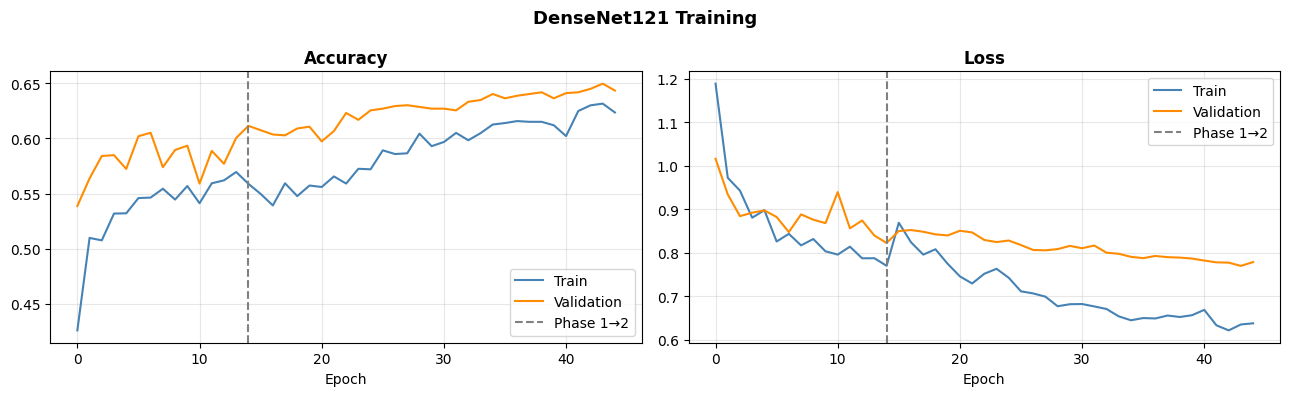

Val accuracy improved: 0.539 → 0.650


In [21]:
# Cell 6 — Training History Plot
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_los = history1.history['val_loss']     + history2.history['val_loss']
p1_end  = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tr, va, title in [
    (axes[0], acc,  val_acc, 'Accuracy'),
    (axes[1], loss, val_los, 'Loss'),
]:
    ax.plot(tr, label='Train',      color='steelblue')
    ax.plot(va, label='Validation', color='darkorange')
    ax.axvline(p1_end - 1, color='gray', linestyle='--', label='Phase 1→2')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('DenseNet121 Training', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Val accuracy improved: {val_acc[0]:.3f} → {max(val_acc):.3f}')

In [22]:
# Cell 7 — Build Feature Extractor & Extract Features
# DenseNet121 GAP = 1024-dim features
GAP_DIM = 1024

gap_layer         = model.get_layer('gap_features')
feature_extractor = Model(inputs=model.input, outputs=gap_layer.output)

assert feature_extractor.output_shape[-1] == GAP_DIM, \
    f'Expected ({GAP_DIM},), got {feature_extractor.output_shape}'
print(f'✓ Feature extractor: {feature_extractor.output_shape}')

extract_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_gen_noaug = extract_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

def extract_features(gen, extractor, label=''):
    gen.reset()
    print(f'  {label}: {len(gen.filenames)} images...')
    return extractor.predict(gen, verbose=1), gen.classes

print('\nExtracting features...')
X_train, y_train = extract_features(train_gen_noaug, feature_extractor, 'Train')
X_val,   y_val   = extract_features(val_gen,         feature_extractor, 'Val')
X_test,  y_test  = extract_features(test_gen,        feature_extractor, 'Test')

print(f'\nShapes → Train:{X_train.shape}  Val:{X_val.shape}  Test:{X_test.shape}')
print(f'Feature stats → mean={X_train.mean():.4f}, std={X_train.std():.4f}')
if X_train.std() < 0.01:
    print('  ⚠ WARNING: near-zero std — possible preprocessing mismatch')
else:
    print('  ✓ Feature variance is healthy')

✓ Feature extractor: (None, 1024)
Found 4479 images belonging to 4 classes.

Extracting features...
  Train: 4479 images...
280/280 [==============================] - 21s 69ms/step
  Val: 1279 images...
80/80 [==============================] - 5s 69ms/step
  Test: 642 images...
41/41 [==============================] - 3s 69ms/step

Shapes → Train:(4479, 1024)  Val:(1279, 1024)  Test:(642, 1024)
Feature stats → mean=0.4983, std=0.6713
  ✓ Feature variance is healthy


In [23]:
# Cell 8 — SMOTE + XGBoost Training
from imblearn.over_sampling import SMOTE
from sklearn.metrics import balanced_accuracy_score

X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

print('Class distribution BEFORE SMOTE:')
unique, counts = np.unique(y_full, return_counts=True)
for idx, count in zip(unique, counts):
    print(f'  [{idx}] {CLASS_NAMES[idx]:20s}: {count:5d}')

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_full, y_full)

print('\nClass distribution AFTER SMOTE:')
unique2, counts2 = np.unique(y_resampled, return_counts=True)
for idx, count in zip(unique2, counts2):
    print(f'  [{idx}] {CLASS_NAMES[idx]:20s}: {count:5d}')

n_real = len(y_full)
weights_resampled = np.ones(len(y_resampled), dtype=np.float32)
weights_resampled[n_real:] = 0.75
print(f'\nReal samples: {n_real:,} | Synthetic: {len(y_resampled)-n_real:,}')

xgb_model = XGBClassifier(
    n_estimators     = 600,
    max_depth        = 5,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    min_child_weight = 1,
    gamma            = 0.05,
    reg_lambda       = 1.5,
    reg_alpha        = 0.1,
    objective        = 'multi:softprob',
    num_class        = 4,
    random_state     = 42,
    eval_metric      = 'mlogloss',
    n_jobs           = -1,
)

print('\nTraining XGBoost on SMOTE-balanced features...')
xgb_model.fit(
    X_resampled, y_resampled,
    sample_weight = weights_resampled,
    eval_set      = [(X_test, y_test)],
    verbose       = 100
)

y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

print(f'\nTest Accuracy     : {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

print('Prediction distribution:')
cm_raw = confusion_matrix(y_test, y_pred)
for i, name in enumerate(CLASS_NAMES):
    n_true = cm_raw[i, :].sum()
    n_pred = cm_raw[:, i].sum()
    flag   = '  <- STILL ZERO' if n_pred == 0 else ''
    print(f'  [{i}] {name:20s}: true={n_true:4d}, predicted={n_pred:4d}{flag}')

Class distribution BEFORE SMOTE:
  [0] MildDemented        :   806
  [1] ModerateDemented    :    56
  [2] NonDemented         :  2880
  [3] VeryMildDemented    :  2016

Class distribution AFTER SMOTE:
  [0] MildDemented        :  2880
  [1] ModerateDemented    :  2880
  [2] NonDemented         :  2880
  [3] VeryMildDemented    :  2880

Real samples: 5,758 | Synthetic: 5,762

Training XGBoost on SMOTE-balanced features...
[0]	validation_0-mlogloss:1.36925
[100]	validation_0-mlogloss:0.77199
[200]	validation_0-mlogloss:0.61861
[300]	validation_0-mlogloss:0.53867
[400]	validation_0-mlogloss:0.48480
[500]	validation_0-mlogloss:0.44534
[599]	validation_0-mlogloss:0.41285

Test Accuracy     : 0.8489
Balanced Accuracy : 0.8408

Classification Report:
                  precision    recall  f1-score   support

    MildDemented      0.843     0.778     0.809        90
ModerateDemented      1.000     0.875     0.933         8
     NonDemented      0.884     0.884     0.884       320
VeryMildDeme

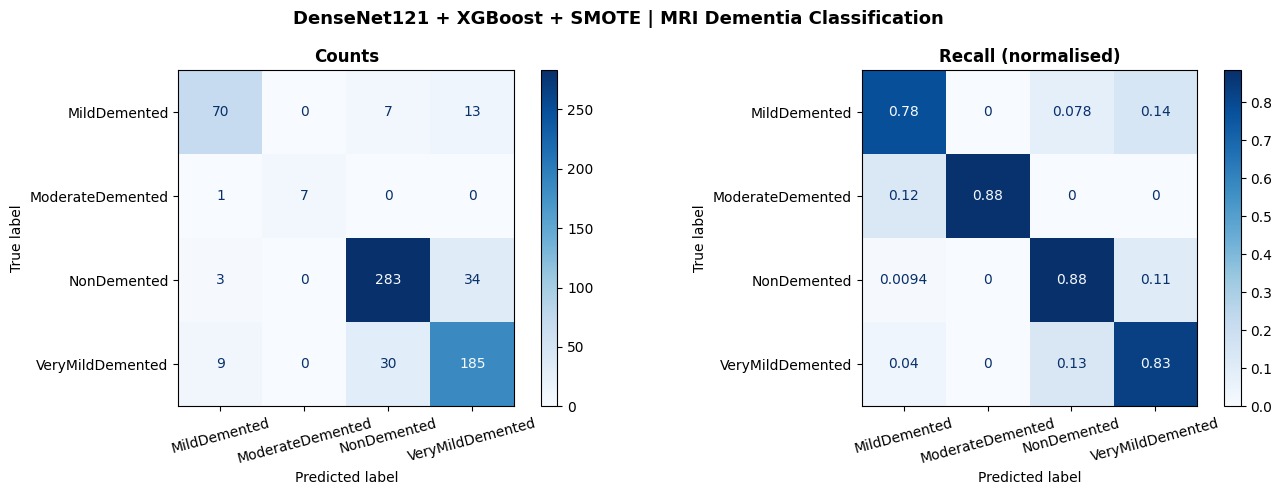

In [24]:
# Cell 9 — Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=CLASS_NAMES,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Counts', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelrotation=15)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=CLASS_NAMES,
    cmap='Blues', ax=axes[1], normalize='true'
)
axes[1].set_title('Recall (normalised)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=15)

plt.suptitle('DenseNet121 + XGBoost + SMOTE | MRI Dementia Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

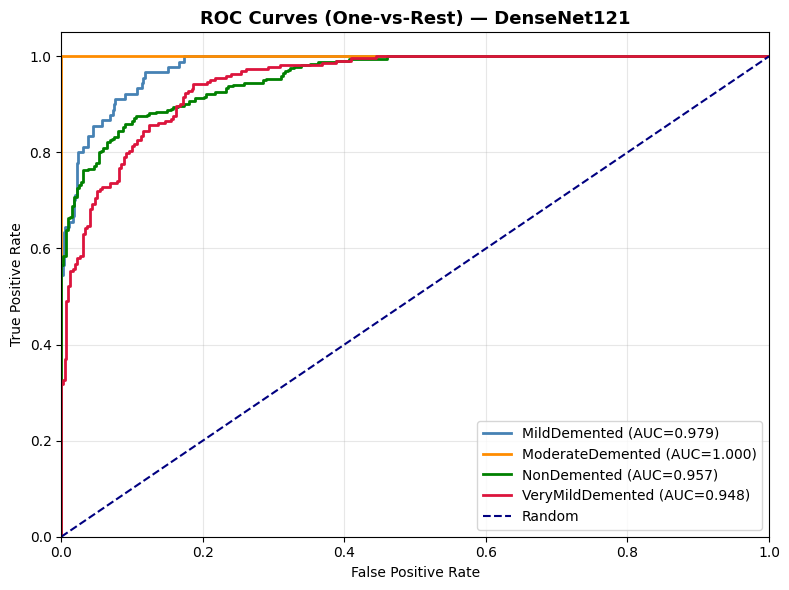

Macro-average AUC: 0.9710


In [25]:
# Cell 10 — ROC Curves
y_test_bin = label_binarize(y_test, classes=list(range(4)))
colors = ['steelblue', 'darkorange', 'green', 'crimson']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')

ax.plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--', label='Random')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest) — DenseNet121', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
print(f'Macro-average AUC: {macro_auc:.4f}')

In [26]:
# Cell 11 — Sync Verification
print('Verifying model sync...')
assert feature_extractor.output_shape[-1] == 1024, 'Wrong feature shape!'
print(f'Feature extractor : {feature_extractor.output_shape}  ✓')
print()

sync_results = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_dir  = os.path.join(train_dir, cls_name)
    img_file = next(
        (f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))),
        None
    )
    if not img_file: continue
    arr  = np.array(
        Image.open(os.path.join(cls_dir, img_file)).convert('RGB').resize((IMG_SIZE, IMG_SIZE)),
        dtype=np.float32
    )
    arr  = preprocess_input(np.expand_dims(arr, 0))
    feat = feature_extractor.predict(arr, verbose=0)
    prob = xgb_model.predict_proba(feat)[0]
    pred = int(np.argmax(prob))
    ok   = pred == cls_idx
    sync_results.append(ok)
    icon = '✅ OK   ' if ok else '❌ WRONG'
    print(f'  {icon} [{cls_idx}] {cls_name:20s} → [{pred}] {CLASS_NAMES[pred]} ({prob[pred]*100:.1f}%)')

n_ok = sum(sync_results)
print(f'\nSync check: {n_ok}/{len(sync_results)} correct on training samples')
if n_ok >= len(sync_results) // 2:
    print('✅ Safe to save — proceed to Cell 12')
else:
    print('⚠ WARNING: Do Kernel → Restart & Run All before saving')

Verifying model sync...
Feature extractor : (None, 1024)  ✓

  ✅ OK    [0] MildDemented         → [0] MildDemented (84.1%)
  ✅ OK    [1] ModerateDemented     → [1] ModerateDemented (55.8%)
  ✅ OK    [2] NonDemented          → [2] NonDemented (50.9%)
  ✅ OK    [3] VeryMildDemented     → [3] VeryMildDemented (65.4%)

Sync check: 4/4 correct on training samples
✅ Safe to save — proceed to Cell 12


In [27]:
# Cell 12 — Save Models
keras_path = os.path.join(MODELS_DIR, 'mri_densenet121_finetuned.keras')
xgb_path   = os.path.join(MODELS_DIR, 'mri_xgb_densenet.pkl')

model.save(keras_path)
joblib.dump(xgb_model, xgb_path)

print('✓ Saved:')
print(f'  {keras_path}')
print(f'  {xgb_path}')
print()
print('Next steps:')
print('  1. Copy both files above to your web app PC models/ folder')
print('  2. Update app_debug.py to point to the new filenames:')
print('       keras_path = "models/mri_densenet121_finetuned.keras"')
print('       xgb_path   = "models/mri_xgb_densenet.pkl"')
print('  3. Update IMG_SIZE in the web app to 224 (was 300)')
print('  4. Restart the web app')

✓ Saved:
  C:\Project\Starting\models\mri_densenet121_finetuned.keras
  C:\Project\Starting\models\mri_xgb_densenet.pkl

Next steps:
  1. Copy both files above to your web app PC models/ folder
  2. Update app_debug.py to point to the new filenames:
       keras_path = "models/mri_densenet121_finetuned.keras"
       xgb_path   = "models/mri_xgb_densenet.pkl"
  3. Update IMG_SIZE in the web app to 224 (was 300)
  4. Restart the web app
